In [ ]:
# !pip install bitsandbytes transformers accelerate captum

In [ ]:
from google.colab import drive, files
drive.mount('/content/drive')

In [2]:
import os
import sys

path = os.getcwd()
while True:
    if 'utils.py' in os.listdir(path):
        if path not in sys.path:
            sys.path.append(path)
        break
    new_path = os.path.dirname(path)
    if new_path == path:
        upload_utils = files.upload()
        break
    path = new_path

import utils
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
import torch
import random

/opt/anaconda3/envs/nlp/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Global Parameters of Notebook
global_params = {'dataset_type': 'qnli',
                'quantization': '4bit',
                'training_mode': 'few shot',
                'model_id': 'google/gemma-2-9b-it'}

# Create checkpoint
checkpoint_path = utils.create_checkpoint_path(params=global_params)

Saving to: /Users/giorgosdikaios/Library/Mobile Documents/com~apple~CloudDocs/Desktop/DAMA_EAP/NLI_Study/Notebooks/QNLI_Notebooks/QNLI_gemma_2_9b_it/Few-Shot/checkpoint_qnli_gemma_2_9b_it_4bit_few_shot.pt


In [ ]:
utils.hf_login("HF_TOKEN")

In [ ]:
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4"
)

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(global_params['model_id'])
model = AutoModelForCausalLM.from_pretrained(
    global_params['model_id'],
    device_map="auto",
    quantization_config=quantization_config,
    attn_implementation="eager"
    )

# Add padding token to the tokenizer
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"

# Change the model to evaluation mode
model.eval()

tokenizer_config.json:   0%|          | 0.00/47.0k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/4.24M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/857 [00:00<?, ?B/s]

...

model-00002-of-00004.safetensors:   0%|          | 0.00/4.95G [00:00<?, ?B/s]

model-00004-of-00004.safetensors:   0%|          | 0.00/3.67G [00:00<?, ?B/s]

model-00003-of-00004.safetensors:   0%|          | 0.00/4.96G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

In [ ]:
# Lock 1 examples to be used for few shot
qnli_val = pd.read_csv('qnli_val.csv')
qnli_val["label"] = qnli_val["label"].map({0: "entailment", 1: "not entailment"})

demo_idxs = np.load('qnli_few_shot_example_idx_pool.npy')

k = 1 # Examples to lock
demo_examples = qnli_val.iloc[demo_idxs[:k]]
qnli_val_few_shot = qnli_val.drop(qnli_val.index[demo_idxs])

In [5]:
demo_examples

,question,sentence,label,idx
5238,What was the first television series to featur...,"For its part, the television network produced ...",not entailment,5238
912,What did Lempicka represent better than anyone...,No one will ever see the Warsaw I knew.,not entailment,912
204,The Ottoman empire controlled territory on thr...,"During the 16th and 17th centuries, in particu...",entailment,204
2253,What famous composer used a Lutheran hymn in h...,Luther adopted a preexisting Johann Walter tun...,not entailment,2253
2006,What book recognizes the importance of the Cha...,The Book of Discipline also recognizes the imp...,entailment,2006
1828,What is another name for a coal supply bin?,Other components are often present; pumps (suc...,not entailment,1828
1143,What did Distributed Adaptive Message Block Sw...,"Starting in the late 1950s, American computer ...",entailment,1143
839,What is set up to scrutinize private bills sub...,A further type of committee is normally set up...,entailment,839
4467,What did the acronym AAP stand for?,Astronauts would continue to use the CSM as a ...,not entailment,4467
712,How would the word apothecary be viewed by con...,Often the place that did this was called an ap...,entailment,712


In [6]:
# Make examples for prompt
prompt_examples = ''
for i in range(len(demo_examples)):
    prompt_examples += f"Example {i+1}\nQuestion: {demo_examples.iloc[i]['question']}\nSentence: {demo_examples.iloc[i]['sentence']}\nAnswer: {demo_examples.iloc[i]['label']} \n\n"

print(prompt_examples)

Example 1
Question: What was the first television series to feature an openly gay character?
Sentence: For its part, the television network produced a few new hits during 1977: January saw the premiere of Roots, a miniseries based on an Alex Haley novel that was published the previous year; in September, The Love Boat, a comedy-drama anthology series produced by Aaron Spelling which was based around the crew of a cruise ship and featured three stories centered partly on the ship's various passengers; although critically lambasted, the series turned out to be a ratings success and lasted nine seasons.
Answer: not entailment 

Example 2
Question: What did Lempicka represent better than anyone else?
Sentence: No one will ever see the Warsaw I knew.
Answer: not entailment 

Example 3
Question: The Ottoman empire controlled territory on three continents, Africa, Asia and which other?
Sentence: During the 16th and 17th centuries, in particular at the height of its power under the reign of Su

In [7]:
qnli_val_few_shot.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5453 entries, 0 to 5452
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   question  5453 non-null   object
 1   sentence  5453 non-null   object
 2   label     5453 non-null   object
 3   idx       5453 non-null   int64 
dtypes: int64(1), object(3)
memory usage: 170.5+ KB


In [8]:
qnli_val_few_shot.head()

,question,sentence,label,idx
0,What came into force after the new constitutio...,"As of that day, the new constitution heralding...",entailment,0
1,What is the first major city in the stream of ...,The most important tributaries in this area ar...,not entailment,1
2,What is the minimum required if you want to te...,In most provinces a second Bachelor's Degree s...,not entailment,2
3,How was Temüjin kept imprisoned by the Tayichi...,The Tayichi'ud enslaved Temüjin (reportedly wi...,entailment,3
4,"What did Herr Gott, dich loben wir become know...","He paraphrased the Te Deum as ""Herr Gott, dich...",not entailment,4


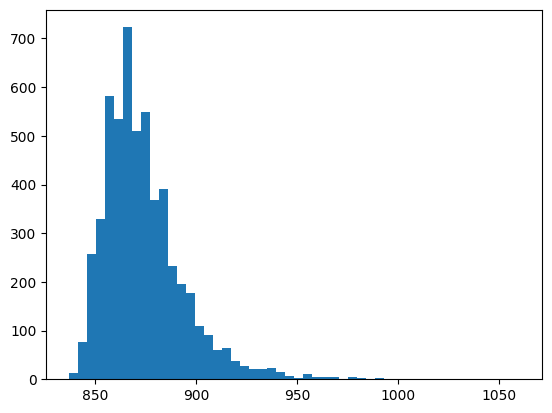

Max prompt length: 1060
Max label length: 3


In [11]:
# Find the max_length for tokenization to avoid wasting computing.
utils.find_max_length(qnli_val_few_shot, tokenizer=tokenizer, dataset_type=global_params['dataset_type'], examples=prompt_examples)

In [13]:
prompt_lengths, _ = utils.get_lengths(qnli_val_few_shot, tokenizer, global_params['dataset_type'], examples=prompt_examples)
df = pd.DataFrame(prompt_lengths, columns=["length"])
tokens = 1000 # Max length to check
n = (df["length"] > tokens).sum() # Number of prompts with # > tokens
percent = round(n/len(df)*100, 3)
print(f"Number of examples that have over {tokens} tokens and will be truncated: {n} out of {len(df)} examples or {percent}%")

Number of examples that have over 1000 tokens and will be truncated: 2 out of 5453 examples or 0.037%


In [14]:
# Define dataset and create a dataloader.
dataset_test = utils.MyDataset_few_shot(dataframe=qnli_val_few_shot,
                                        examples=prompt_examples,
                                        tokenizer=tokenizer,
                                        dataset_type=global_params['dataset_type'],
                                        prompt_max_length=1000,
                                        label_max_length=3)

batch_size = 16 # Change batch size according to GPU
dataloader = DataLoader(dataset_test, batch_size=batch_size, shuffle=False)

In [15]:
# Show an example prompt
print(dataset_test[0]['prompt'])

Examples:
Example 1
Question: What was the first television series to feature an openly gay character?
Sentence: For its part, the television network produced a few new hits during 1977: January saw the premiere of Roots, a miniseries based on an Alex Haley novel that was published the previous year; in September, The Love Boat, a comedy-drama anthology series produced by Aaron Spelling which was based around the crew of a cruise ship and featured three stories centered partly on the ship's various passengers; although critically lambasted, the series turned out to be a ratings success and lasted nine seasons.
Answer: not entailment 

Example 2
Question: What did Lempicka represent better than anyone else?
Sentence: No one will ever see the Warsaw I knew.
Answer: not entailment 

Example 3
Question: The Ottoman empire controlled territory on three continents, Africa, Asia and which other?
Sentence: During the 16th and 17th centuries, in particular at the height of its power under the r

In [ ]:
# Test
predictions, gold_labels, batch_probs = utils.test_run(model=model,
                                          dataloader=dataloader,
                                          tokenizer=tokenizer,
                                          dataset_type=global_params['dataset_type'])

for i, pair in enumerate(zip(predictions, gold_labels)):
    print(pair, batch_probs[i])

neutral
neutral
neutral
entailment


In [ ]:
from tqdm import tqdm

# Load checkpoint if it exists
predicted_labels, gold_labels, start_batch = utils.load_checkpoint(checkpoint_path=checkpoint_path)
labels = utils.get_labels(global_params['dataset_type'])

# Loop over the batches
with torch.no_grad():
    for i, batch in enumerate(tqdm(dataloader, desc="Evaluating", unit="batch")):

        # Continue from last checkpoint
        if i < start_batch:
            continue

        input_ids_batch = batch["input_ids"].to(model.device) # Move to GPU
        attention_mask_batch = batch["attention_mask"].to(model.device) # Move to GPU
        gold_labels_batch = batch["labels"] # Keep to CPU

        batch_probs = utils.get_model_probs(batch_input_ids=input_ids_batch,
                                      batch_attention_mask=attention_mask_batch,
                                      dataset_type=global_params['dataset_type'],
                                      model=model,
                                      tokenizer=tokenizer)

        batch_pred_indices = torch.argmax(batch_probs, dim=1)
        batch_pred_labels = [labels[i] for i in batch_pred_indices]

        predicted_labels.extend(batch_pred_labels)
        gold_labels.extend(gold_labels_batch)

        # Save checkpoint
        if i % 50 == 0 or i == len(dataloader) - 1:
            torch.save({"predicted_labels": predicted_labels,
                        "gold_labels": gold_labels,
                        "batch_no": i+1}, checkpoint_path)

            print(f"Checkpoint saved: {i+1}, {checkpoint_path}")

Saving to: /Users/giorgosdikaios/Library/Mobile Documents/com~apple~CloudDocs/Desktop/DAMA_EAP/NLI_Study/Notebooks/QNLI_Notebooks/QNLI_gemma_2_9b_it/Few-Shot/checkpoint_qnli_gemma_2_9b_it_4bit_few_shot_1_examples.pt
Checkpoint found.
Saving to: /Users/giorgosdikaios/Library/Mobile Documents/com~apple~CloudDocs/Desktop/DAMA_EAP/NLI_Study/Notebooks/QNLI_Notebooks/QNLI_gemma_2_9b_it/Few-Shot/checkpoint_qnli_gemma_2_9b_it_4bit_few_shot_1_examples_opposite.pt
Checkpoint found.
Saving to: /Users/giorgosdikaios/Library/Mobile Documents/com~apple~CloudDocs/Desktop/DAMA_EAP/NLI_Study/Notebooks/QNLI_Notebooks/QNLI_gemma_2_9b_it/Few-Shot/checkpoint_qnli_gemma_2_9b_it_4bit_few_shot_2_examples.pt
Checkpoint found.
Saving to: /Users/giorgosdikaios/Library/Mobile Documents/com~apple~CloudDocs/Desktop/DAMA_EAP/NLI_Study/Notebooks/QNLI_Notebooks/QNLI_gemma_2_9b_it/Few-Shot/checkpoint_qnli_gemma_2_9b_it_4bit_few_shot_3_examples.pt
Checkpoint found.
Saving to: /Users/giorgosdikaios/Library/Mobile Documen

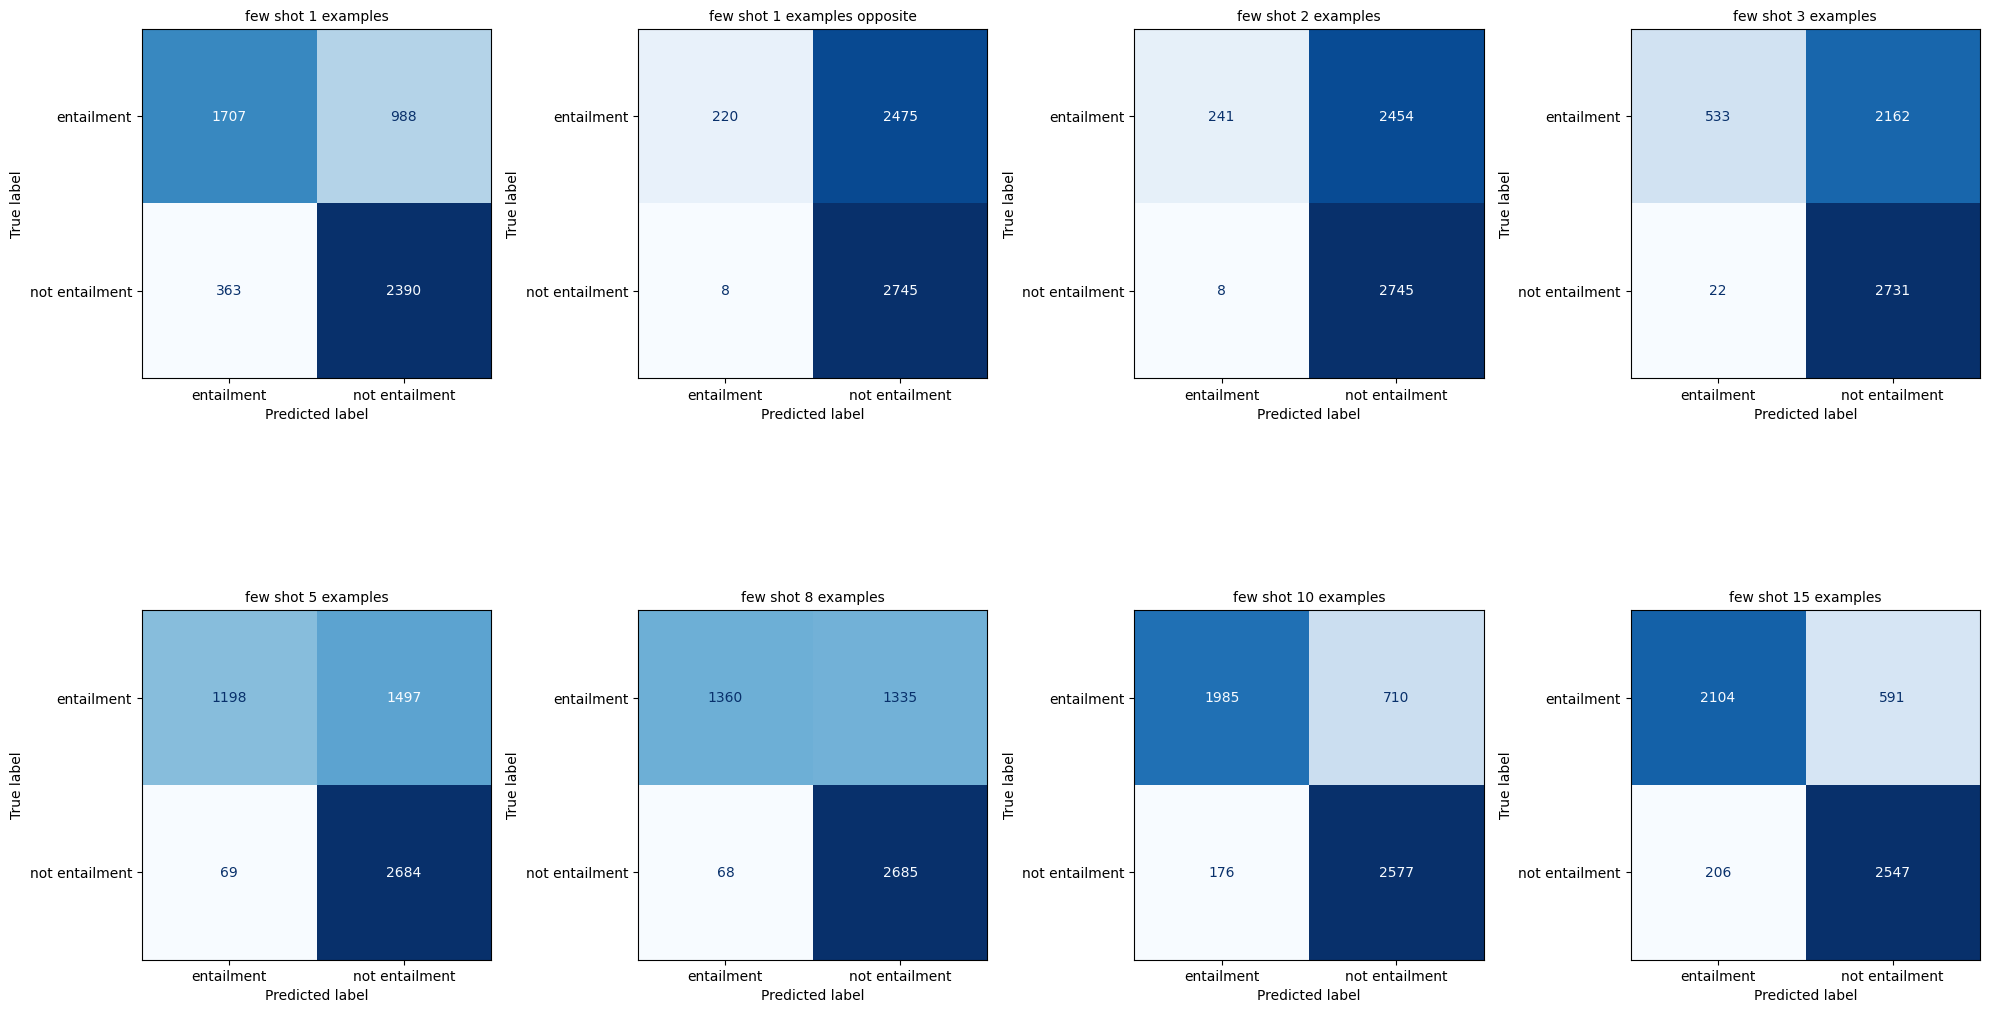

In [6]:
import matplotlib.pyplot as plt

examples_no = [1, 2, 3, 5, 8, 10, 15]
fig, axes = plt.subplots(2, 4, figsize=(20,12))
axes = axes.flatten()
accs, precisions, recalls, f1s, mccs, kappas = [], [], [], [], [], []

idx = 0
for k in examples_no:
    global_params = {
        'dataset_type': 'qnli',
        'quantization': '4bit',
        'training_mode': f'few shot {k} examples',
        'model_id': 'google/gemma-2-9b-it'
    }

    checkpoint_path = utils.create_checkpoint_path(params=global_params)
    predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)

    acc, precision, recall, f1, mcc, kappa = utils.get_metrics(
                                            predicted_labels=predicted_labels,
                                            gold_labels=gold_labels,
                                            params=global_params,
                                            ax=axes[idx]
                                            )   
    accs.append(round(acc, 4))
    precisions.append(round(precision, 4))
    recalls.append(round(recall, 4))
    f1s.append(round(f1, 4))
    mccs.append(round(mcc, 4))
    kappas.append(round(kappa, 4))

    idx += 1

    if k == 1:
        global_params = {
        'dataset_type': 'qnli',
        'quantization': '4bit',
        'training_mode': f'few shot {k} examples opposite',
        'model_id': 'google/gemma-2-9b-it'
    }

        checkpoint_path = utils.create_checkpoint_path(params=global_params)
        predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)

        acc, precision, recall, f1, mcc, kappa = utils.get_metrics(
                                                predicted_labels=predicted_labels,
                                                gold_labels=gold_labels,
                                                params=global_params,
                                                ax=axes[idx]
                                                )   
        accs.append(round(acc, 4))
        precisions.append(round(precision, 4))
        recalls.append(round(recall, 4))
        f1s.append(round(f1, 4))
        mccs.append(round(mcc, 4))
        kappas.append(round(kappa, 4))

        idx += 1


plt.tight_layout()
plt.show()

In [8]:
idx = [f"{k} examples" for k in examples_no]
idx.append("1 examples opposite")

metrics_df = pd.DataFrame(
    {"Accuracy": accs,
     "Precision": precisions,
     "Recalls": recalls,
    "F1": f1s,
    "MCC": mccs,
    "Kappa": kappas},
    index= idx
)
metrics_df

,Accuracy,Precision,Recalls,F1,MCC,Kappa
1 examples,0.7520,0.7661,0.7508,0.7481,0.5166,0.5028
2 examples,0.5442,0.7454,0.5394,0.4196,0.1966,0.0795
3 examples,0.5481,0.7479,0.5433,0.4271,0.2071,0.0874
5 examples,0.5991,0.7593,0.5949,0.5212,0.3137,0.1914
8 examples,0.7126,0.7937,0.7097,0.6895,0.4964,0.4218
10 examples,0.7425,0.8101,0.7400,0.7263,0.5456,0.4823
15 examples,0.8374,0.8513,0.8363,0.8354,0.6874,0.6740
1 examples opposite,0.8537,0.8612,0.8529,0.8527,0.7141,0.7069


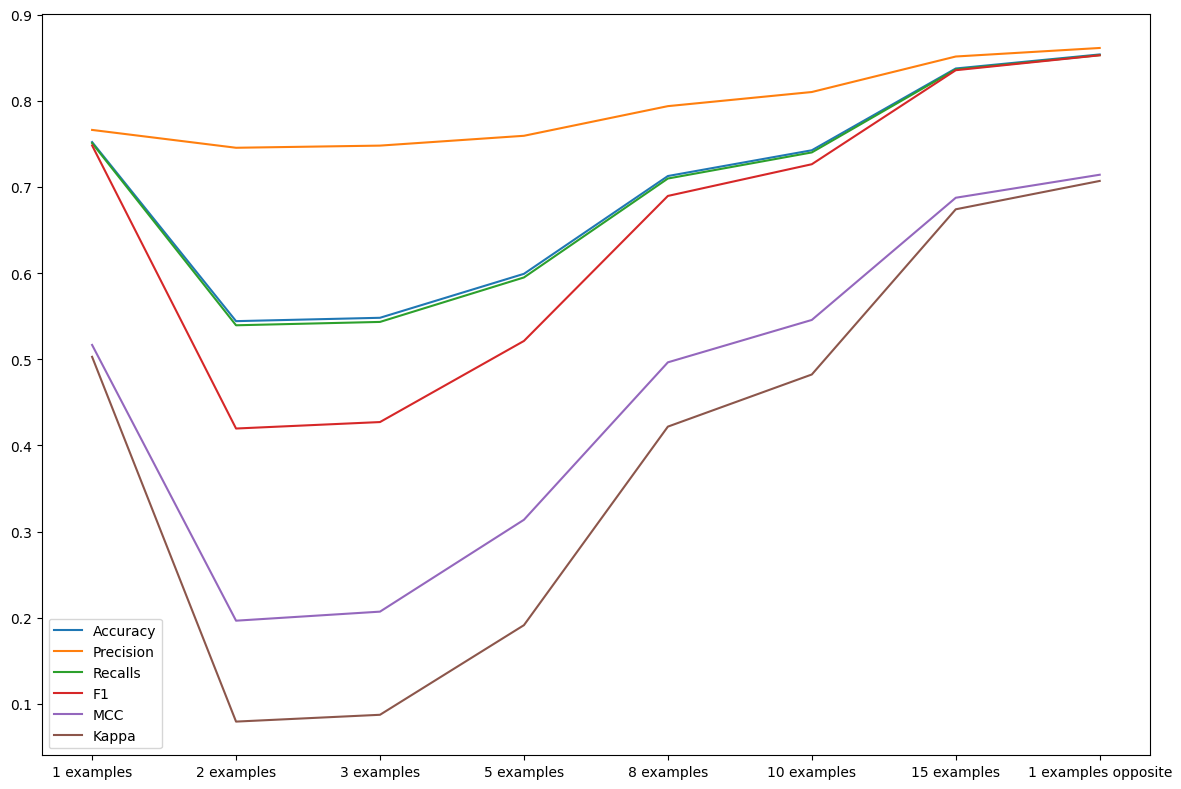

In [9]:
fig, ax = plt.subplots(figsize=(12, 8))
metrics_df.plot(kind='line', ax=ax)
plt.tight_layout()
plt.show()